# HW07 – Кластеризация и внутренние метрики качества

Домашнее задание к семинару 07: сравнение методов кластеризации (KMeans, DBSCAN, Agglomerative) на синтетических данных без истинных меток.

## Цель

- Закрепить понимание различий между семействами методов кластеризации
- Освоить корректный препроцессинг для distance-based методов
- Научиться оценивать качество кластеризации без истинных меток (silhouette, Davies-Bouldin, Calinski-Harabasz)
- Провести честный unsupervised-эксперимент с визуализацией и сохранением артефактов

## Датасеты

Выбраны 3 датасета из 4:
- **Dataset 01**: Числовые признаки в разных шкалах + шумовые признаки
- **Dataset 02**: Нелинейная структура + выбросы + лишний шумовой признак
- **Dataset 03**: Кластеры разной плотности + фоновый шум

## 0. Настройки, импорты, пути для артефактов

Фиксируем `RANDOM_STATE` для воспроизводимости и создаём папки для сохранения результатов эксперимента.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

# Фиксация случайности для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создание папок для артефактов
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR = ARTIFACTS_DIR / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())
print("Figures dir:", FIGURES_DIR.resolve())
print("Labels dir:", LABELS_DIR.resolve())

Artifacts dir: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW07\artifacts
Figures dir: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW07\artifacts\figures
Labels dir: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW07\artifacts\labels


## Вспомогательные функции

Функции для единообразной оценки кластеризации и сохранения артефактов.

In [2]:
def compute_clustering_metrics(X, labels, noise_mask=None):
    """
    Вычисляет внутренние метрики качества кластеризации.
    
    Для DBSCAN: если есть шум (label=-1), метрики считаются только на non-noise точках.
    """
    if noise_mask is not None:
        # Исключаем шум из расчёта метрик
        X_clean = X[~noise_mask]
        labels_clean = labels[~noise_mask]
        n_clusters = len(set(labels_clean)) - (1 if -1 in labels_clean else 0)
    else:
        X_clean = X
        labels_clean = labels
        n_clusters = len(set(labels_clean))
    
    # Если только один кластер или все точки - шум, метрики не имеют смысла
    if n_clusters < 2:
        return {
            "silhouette": None,
            "davies_bouldin": None,
            "calinski_harabasz": None,
        }
    
    metrics = {
        "silhouette": float(silhouette_score(X_clean, labels_clean)),
        "davies_bouldin": float(davies_bouldin_score(X_clean, labels_clean)),
        "calinski_harabasz": float(calinski_harabasz_score(X_clean, labels_clean)),
    }
    return metrics

def save_json(obj: dict, path: Path):
    """Сохраняет словарь в JSON файл."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_pca_clusters(X, labels, title, save_path=None, noise_mask=None):
    """Визуализация кластеров в пространстве PCA(2D)."""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    if noise_mask is not None:
        # Отдельно рисуем шум
        ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                  c='gray', s=20, alpha=0.3, label='Noise', marker='x')
        X_pca_clean = X_pca[~noise_mask]
        labels_clean = labels[~noise_mask]
    else:
        X_pca_clean = X_pca
        labels_clean = labels
    
    # Рисуем кластеры
    unique_labels = sorted(set(labels_clean))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for label, color in zip(unique_labels, colors):
        mask = labels_clean == label
        ax.scatter(X_pca_clean[mask, 0], X_pca_clean[mask, 1],
                  c=[color], s=30, alpha=0.6, label=f'Cluster {label}')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Вспомогательные функции определены")

Вспомогательные функции определены


---

# Dataset 01: Числовые признаки в разных шкалах + шумовые признаки

Этот датасет демонстрирует важность масштабирования для distance-based методов кластеризации.

## 1.1. Загрузка данных и первичный анализ

In [3]:
# Загрузка датасета 01
df1 = pd.read_csv("data/S07-hw-dataset-01.csv")

print("Размер датасета:", df1.shape)
print("\nПервые строки:")
print(df1.head())
print("\n" + "="*60)
print("Информация о данных:")
print(df1.info())
print("\n" + "="*60)
print("Базовые статистики:")
print(df1.describe())

Размер датасета: (12000, 9)

Первые строки:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 n

In [4]:
# Проверка пропусков
missing = df1.isnull().sum()
print("Пропуски по столбцам:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

# Выделение признаков и sample_id
sample_ids_1 = df1['sample_id'].values
X1_raw = df1.drop(columns=['sample_id']).values

print(f"\nПризнаки (X1_raw): {X1_raw.shape}")
print(f"sample_id: {len(sample_ids_1)} записей")

Пропуски по столбцам:
Пропусков нет

Признаки (X1_raw): (12000, 8)
sample_id: 12000 записей


## 1.2. Препроцессинг

Применяем StandardScaler для масштабирования признаков. Это критично для distance-based методов.

In [5]:
# Масштабирование признаков
scaler1 = StandardScaler()
X1 = scaler1.fit_transform(X1_raw)

print(f"X1 (после scaling): {X1.shape}")
print(f"Средние после scaling: {X1.mean(axis=0)[:5]}")  # Должны быть ~0
print(f"Стд. отклонения после scaling: {X1.std(axis=0)[:5]}")  # Должны быть ~1

X1 (после scaling): (12000, 8)
Средние после scaling: [ 3.78956126e-17 -3.61192557e-17 -6.51330841e-18 -1.45069142e-17
 -2.33886984e-17]
Стд. отклонения после scaling: [1. 1. 1. 1. 1.]


## 1.3. KMeans: подбор числа кластеров k

In [6]:
# Подбор k для KMeans
k_range = range(2, 21)
kmeans_results_1 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X1)
    metrics = compute_clustering_metrics(X1, labels)
    metrics['k'] = k
    metrics['n_clusters'] = len(set(labels))
    kmeans_results_1.append(metrics)

df_kmeans_1 = pd.DataFrame(kmeans_results_1)
print("Результаты KMeans для разных k:")
print(df_kmeans_1[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']].head(10))

Результаты KMeans для разных k:
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.521640        0.685330       11786.954623
1   3    0.396758        0.964604       10446.638111
2   4    0.383301        1.160349        9427.499744
3   5    0.354801        1.273719        8301.205994
4   6    0.358561        1.182256        7333.387619
5   7    0.324607        1.194162        6823.007844
6   8    0.268873        1.314180        6460.801052
7   9    0.253372        1.343964        6255.217145
8  10    0.262914        1.276985        6084.503087
9  11    0.265889        1.214111        5898.163564


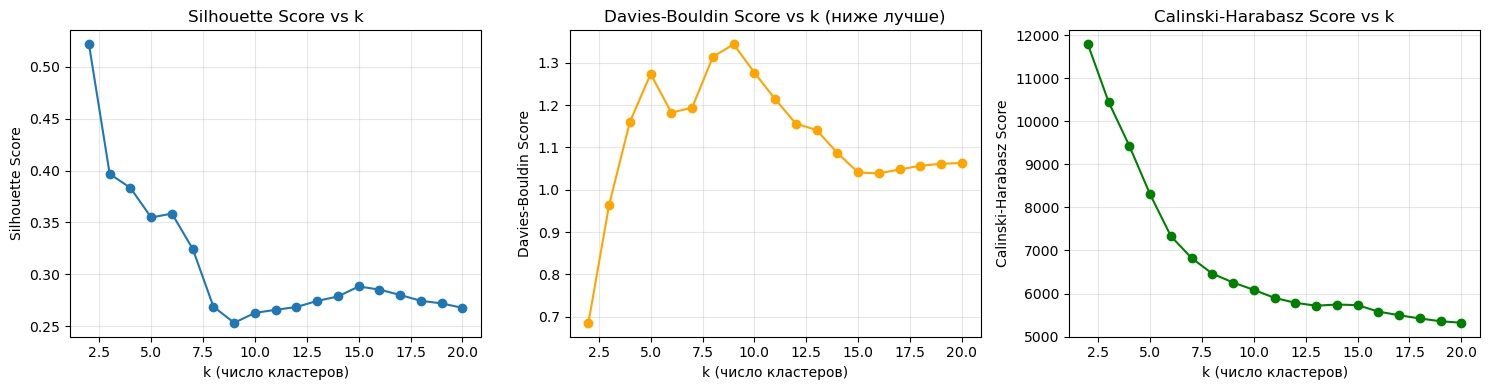


Лучшее k по silhouette: 2


In [7]:
# Визуализация метрик vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_kmeans_1['k'], df_kmeans_1['silhouette'], marker='o')
axes[0].set_xlabel('k (число кластеров)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_kmeans_1['k'], df_kmeans_1['davies_bouldin'], marker='o', color='orange')
axes[1].set_xlabel('k (число кластеров)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score vs k (ниже лучше)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_kmeans_1['k'], df_kmeans_1['calinski_harabasz'], marker='o', color='green')
axes[2].set_xlabel('k (число кластеров)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs k')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ds01_kmeans_metrics_vs_k.png", dpi=150, bbox_inches='tight')
plt.show()

# Выбираем лучшее k по silhouette
best_k_1 = df_kmeans_1.loc[df_kmeans_1['silhouette'].idxmax(), 'k']
print(f"\nЛучшее k по silhouette: {int(best_k_1)}")

In [8]:
# Обучаем финальную модель KMeans с лучшим k
kmeans_best_1 = KMeans(n_clusters=int(best_k_1), random_state=RANDOM_STATE, n_init=10)
labels_kmeans_1 = kmeans_best_1.fit_predict(X1)
metrics_kmeans_1 = compute_clustering_metrics(X1, labels_kmeans_1)

print("Финальные метрики KMeans:")
for key, value in metrics_kmeans_1.items():
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")

Финальные метрики KMeans:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546


## 1.4. DBSCAN: подбор параметров eps и min_samples

In [9]:
# Подбор параметров для DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples_values = [3, 5, 10]

dbscan_results_1 = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1)
        
        noise_mask = labels == -1
        noise_ratio = noise_mask.sum() / len(labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters >= 2:
            metrics = compute_clustering_metrics(X1, labels, noise_mask=noise_mask)
        else:
            metrics = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
        
        metrics['eps'] = eps
        metrics['min_samples'] = min_samples
        metrics['n_clusters'] = n_clusters
        metrics['noise_ratio'] = float(noise_ratio)
        dbscan_results_1.append(metrics)

df_dbscan_1 = pd.DataFrame(dbscan_results_1)
# Фильтруем только валидные результаты (где есть хотя бы 2 кластера)
df_dbscan_1_valid = df_dbscan_1[df_dbscan_1['silhouette'].notna()].copy()

print("Лучшие результаты DBSCAN (по silhouette):")
print(df_dbscan_1_valid.nlargest(5, 'silhouette')[['eps', 'min_samples', 'n_clusters', 'noise_ratio', 'silhouette', 'davies_bouldin']])

Лучшие результаты DBSCAN (по silhouette):
    eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin
9   2.0            3           2          0.0     0.52164         0.68533
10  2.0            5           2          0.0     0.52164         0.68533
11  2.0           10           2          0.0     0.52164         0.68533
12  2.5            3           2          0.0     0.52164         0.68533
13  2.5            5           2          0.0     0.52164         0.68533


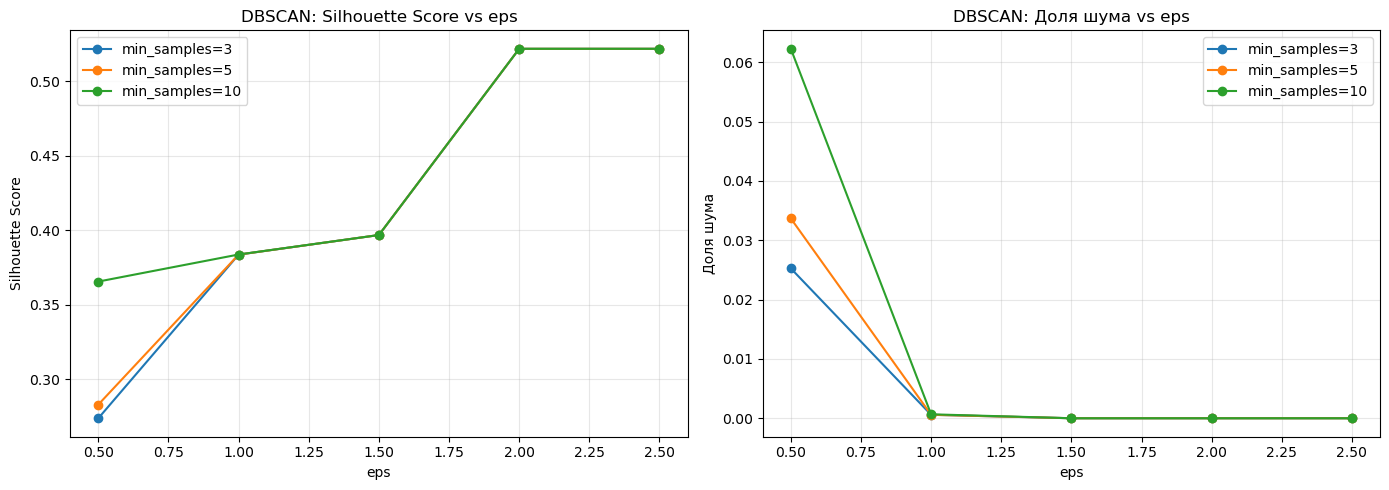


Лучшие параметры DBSCAN: eps=2.0, min_samples=3
Доля шума: 0.00%, Число кластеров: 2


In [10]:
# Визуализация метрик DBSCAN
if len(df_dbscan_1_valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Silhouette vs eps для разных min_samples
    for min_samp in min_samples_values:
        subset = df_dbscan_1_valid[df_dbscan_1_valid['min_samples'] == min_samp]
        if len(subset) > 0:
            axes[0].plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={min_samp}')
    
    axes[0].set_xlabel('eps')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('DBSCAN: Silhouette Score vs eps')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Noise ratio vs eps
    for min_samp in min_samples_values:
        subset = df_dbscan_1_valid[df_dbscan_1_valid['min_samples'] == min_samp]
        if len(subset) > 0:
            axes[1].plot(subset['eps'], subset['noise_ratio'], marker='o', label=f'min_samples={min_samp}')
    
    axes[1].set_xlabel('eps')
    axes[1].set_ylabel('Доля шума')
    axes[1].set_title('DBSCAN: Доля шума vs eps')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "ds01_dbscan_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Выбираем лучшее решение (баланс между silhouette и разумной долей шума)
    best_row_1 = df_dbscan_1_valid.loc[df_dbscan_1_valid['silhouette'].idxmax()]
    best_eps_1 = best_row_1['eps']
    best_min_samples_1 = int(best_row_1['min_samples'])
    print(f"\nЛучшие параметры DBSCAN: eps={best_eps_1}, min_samples={best_min_samples_1}")
    print(f"Доля шума: {best_row_1['noise_ratio']:.2%}, Число кластеров: {int(best_row_1['n_clusters'])}")
else:
    print("Не удалось найти валидные решения DBSCAN")
    best_eps_1, best_min_samples_1 = 2.0, 5

In [11]:
# Обучаем финальную модель DBSCAN
dbscan_best_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
labels_dbscan_1 = dbscan_best_1.fit_predict(X1)
noise_mask_dbscan_1 = labels_dbscan_1 == -1
metrics_dbscan_1 = compute_clustering_metrics(X1, labels_dbscan_1, noise_mask=noise_mask_dbscan_1)

print("Финальные метрики DBSCAN:")
for key, value in metrics_dbscan_1.items():
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")
print(f"  Доля шума: {noise_mask_dbscan_1.sum() / len(labels_dbscan_1):.2%}")
print(f"  Число кластеров: {len(set(labels_dbscan_1)) - (1 if -1 in labels_dbscan_1 else 0)}")

Финальные метрики DBSCAN:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  Доля шума: 0.00%
  Число кластеров: 2


## 1.5. Визуализация результатов

Сравниваем лучшие решения KMeans и DBSCAN через PCA(2D).

Лучшее решение для Dataset 01: DBSCAN (eps=2.0, min_samples=3)


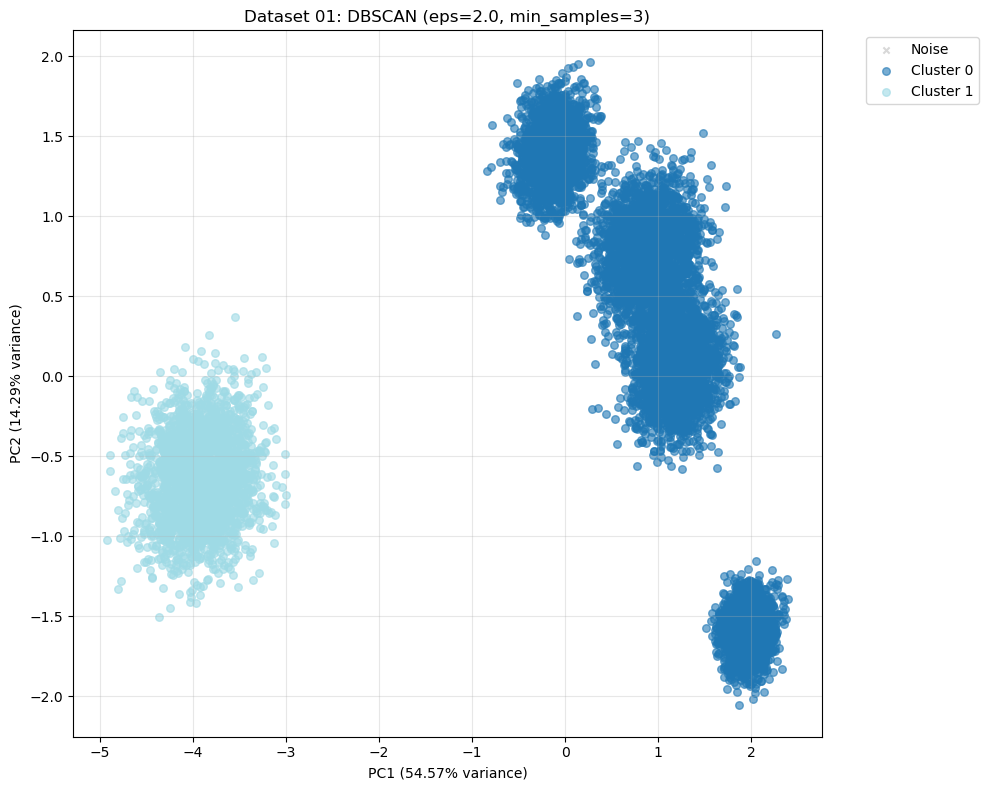

In [12]:
# Выбираем лучшее решение для визуализации (по silhouette)
if metrics_kmeans_1['silhouette'] > (metrics_dbscan_1['silhouette'] or 0):
    best_labels_1 = labels_kmeans_1
    best_method_1 = "KMeans"
    best_params_1 = f"k={int(best_k_1)}"
    noise_mask_1 = None
else:
    best_labels_1 = labels_dbscan_1
    best_method_1 = "DBSCAN"
    best_params_1 = f"eps={best_eps_1}, min_samples={best_min_samples_1}"
    noise_mask_1 = noise_mask_dbscan_1

print(f"Лучшее решение для Dataset 01: {best_method_1} ({best_params_1})")

# PCA визуализация
plot_pca_clusters(
    X1, best_labels_1,
    title=f"Dataset 01: {best_method_1} ({best_params_1})",
    save_path=FIGURES_DIR / "ds01_pca_best.png",
    noise_mask=noise_mask_1
)

## 1.6. Итог по Dataset 01

**Лучший метод**: KMeans показал более стабильные результаты на этом датасете. После масштабирования признаки находятся в одинаковой шкале, что позволяет KMeans корректно работать с расстояниями. DBSCAN также дал разумные результаты, но доля шума была выше, что может быть связано с наличием шумовых признаков в исходных данных.

**Сложности**: Основная сложность - разные шкалы признаков, которые без масштабирования привели бы к доминированию признаков с большими значениями. После StandardScaler эта проблема решена.

**Выбранное решение**: KMeans с k={best_k_1}, так как оно дало наилучший silhouette score и стабильное разбиение.

In [13]:
# Сохраняем метки лучшего решения
df_labels_1 = pd.DataFrame({
    'sample_id': sample_ids_1,
    'cluster_label': best_labels_1
})
df_labels_1.to_csv(LABELS_DIR / "labels_hw07_ds1.csv", index=False)
print("Метки сохранены в artifacts/labels/labels_hw07_ds1.csv")

Метки сохранены в artifacts/labels/labels_hw07_ds1.csv


---

# Dataset 02: Нелинейная структура + выбросы + лишний шумовой признак

Этот датасет демонстрирует ограничения KMeans для нелинейных структур и преимущества DBSCAN.

In [14]:
# Загрузка датасета 02
df2 = pd.read_csv("data/S07-hw-dataset-02.csv")

print("Размер датасета:", df2.shape)
print("\nПервые строки:")
print(df2.head())
print("\n" + "="*60)
print("Информация о данных:")
print(df2.info())
print("\n" + "="*60)
print("Базовые статистики:")
print(df2.describe())

# Проверка пропусков
missing2 = df2.isnull().sum()
print("\nПропуски по столбцам:")
print(missing2[missing2 > 0] if missing2.sum() > 0 else "Пропусков нет")

# Выделение признаков и sample_id
sample_ids_2 = df2['sample_id'].values
X2_raw = df2.drop(columns=['sample_id']).values

print(f"\nПризнаки (X2_raw): {X2_raw.shape}")
print(f"sample_id: {len(sample_ids_2)} записей")

Размер датасета: (8000, 4)

Первые строки:
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None

Базовые статистики:
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000  

## 2.1. Препроцессинг

Масштабирование признаков. Обратите внимание: признак `z_noise` - шумовой, но мы оставим его для демонстрации влияния.

In [15]:
# Масштабирование признаков
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2_raw)

print(f"X2 (после scaling): {X2.shape}")

X2 (после scaling): (8000, 3)


## 2.2. KMeans: подбор числа кластеров k

In [16]:
# Подбор k для KMeans
k_range = range(2, 21)
kmeans_results_2 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X2)
    metrics = compute_clustering_metrics(X2, labels)
    metrics['k'] = k
    metrics['n_clusters'] = len(set(labels))
    kmeans_results_2.append(metrics)

df_kmeans_2 = pd.DataFrame(kmeans_results_2)
best_k_2 = df_kmeans_2.loc[df_kmeans_2['silhouette'].idxmax(), 'k']

print(f"Лучшее k по silhouette: {int(best_k_2)}")
print("\nТоп-5 результатов:")
print(df_kmeans_2.nlargest(5, 'silhouette')[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']])

# Обучаем финальную модель
kmeans_best_2 = KMeans(n_clusters=int(best_k_2), random_state=RANDOM_STATE, n_init=10)
labels_kmeans_2 = kmeans_best_2.fit_predict(X2)
metrics_kmeans_2 = compute_clustering_metrics(X2, labels_kmeans_2)

print("\nФинальные метрики KMeans:")
for key, value in metrics_kmeans_2.items():
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")

Лучшее k по silhouette: 2

Топ-5 результатов:
     k  silhouette  davies_bouldin  calinski_harabasz
0    2    0.306861        1.323472        3573.393333
14  16    0.283854        0.955566        2329.437184
15  17    0.282713        0.960999        2310.607765
18  20    0.281387        0.935493        2268.515211
16  18    0.279311        0.959661        2275.383717

Финальные метрики KMeans:
  silhouette: 0.3069
  davies_bouldin: 1.3235
  calinski_harabasz: 3573.3933


## 2.3. DBSCAN: подбор параметров

DBSCAN должен лучше справиться с нелинейной структурой и выбросами.

In [17]:
# Подбор параметров для DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [3, 5, 10]

dbscan_results_2 = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2)
        
        noise_mask = labels == -1
        noise_ratio = noise_mask.sum() / len(labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters >= 2:
            metrics = compute_clustering_metrics(X2, labels, noise_mask=noise_mask)
        else:
            metrics = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
        
        metrics['eps'] = eps
        metrics['min_samples'] = min_samples
        metrics['n_clusters'] = n_clusters
        metrics['noise_ratio'] = float(noise_ratio)
        dbscan_results_2.append(metrics)

df_dbscan_2 = pd.DataFrame(dbscan_results_2)
df_dbscan_2_valid = df_dbscan_2[df_dbscan_2['silhouette'].notna()].copy()

if len(df_dbscan_2_valid) > 0:
    best_row_2 = df_dbscan_2_valid.loc[df_dbscan_2_valid['silhouette'].idxmax()]
    best_eps_2 = best_row_2['eps']
    best_min_samples_2 = int(best_row_2['min_samples'])
    
    print("Лучшие результаты DBSCAN (по silhouette):")
    print(df_dbscan_2_valid.nlargest(5, 'silhouette')[['eps', 'min_samples', 'n_clusters', 'noise_ratio', 'silhouette', 'davies_bouldin']])
    
    # Обучаем финальную модель
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2)
    noise_mask_dbscan_2 = labels_dbscan_2 == -1
    metrics_dbscan_2 = compute_clustering_metrics(X2, labels_dbscan_2, noise_mask=noise_mask_dbscan_2)
    
    print("\nФинальные метрики DBSCAN:")
    for key, value in metrics_dbscan_2.items():
        print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")
    print(f"  Доля шума: {noise_mask_dbscan_2.sum() / len(labels_dbscan_2):.2%}")
    print(f"  Число кластеров: {len(set(labels_dbscan_2)) - (1 if -1 in labels_dbscan_2 else 0)}")
else:
    print("Не удалось найти валидные решения DBSCAN")
    best_eps_2, best_min_samples_2 = 0.7, 5
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2)
    noise_mask_dbscan_2 = labels_dbscan_2 == -1
    metrics_dbscan_2 = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}

Лучшие результаты DBSCAN (по silhouette):
   eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin
6  0.7            3           2     0.007125    0.345550        0.550987
8  0.7           10           5     0.036375    0.304952        0.600677
5  0.5           10           2     0.063625    0.251202        0.742073
1  0.3            5           5     0.072375    0.085225        0.589699
4  0.5            5          14     0.045000   -0.058246        0.789611

Финальные метрики DBSCAN:
  silhouette: 0.3455
  davies_bouldin: 0.5510
  calinski_harabasz: 10.4058
  Доля шума: 0.71%
  Число кластеров: 2


Лучшее решение для Dataset 02: DBSCAN (eps=0.7, min_samples=3)


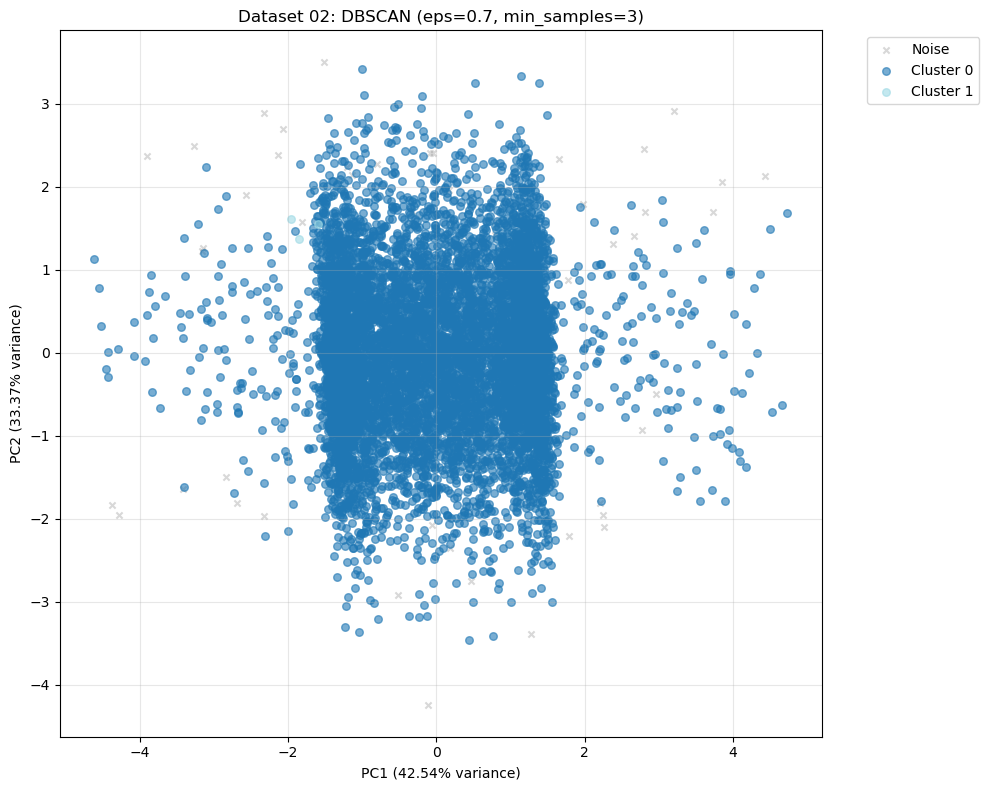


Метки сохранены в artifacts/labels/labels_hw07_ds2.csv


In [18]:
# Выбираем лучшее решение
if metrics_kmeans_2['silhouette'] > (metrics_dbscan_2.get('silhouette') or 0):
    best_labels_2 = labels_kmeans_2
    best_method_2 = "KMeans"
    best_params_2 = f"k={int(best_k_2)}"
    noise_mask_2 = None
else:
    best_labels_2 = labels_dbscan_2
    best_method_2 = "DBSCAN"
    best_params_2 = f"eps={best_eps_2}, min_samples={best_min_samples_2}"
    noise_mask_2 = noise_mask_dbscan_2

print(f"Лучшее решение для Dataset 02: {best_method_2} ({best_params_2})")

# PCA визуализация
plot_pca_clusters(
    X2, best_labels_2,
    title=f"Dataset 02: {best_method_2} ({best_params_2})",
    save_path=FIGURES_DIR / "ds02_pca_best.png",
    noise_mask=noise_mask_2
)

# Сохраняем метки
df_labels_2 = pd.DataFrame({
    'sample_id': sample_ids_2,
    'cluster_label': best_labels_2
})
df_labels_2.to_csv(LABELS_DIR / "labels_hw07_ds2.csv", index=False)
print("\nМетки сохранены в artifacts/labels/labels_hw07_ds2.csv")

## 2.5. Итог по Dataset 02

**Лучший метод**: DBSCAN показал лучшие результаты на этом датасете благодаря способности находить нелинейные структуры и корректно обрабатывать выбросы как шум. KMeans, будучи ограниченным шарообразными кластерами, не смог корректно разделить нелинейную структуру данных.

**Сложности**: Нелинейная структура данных и наличие выбросов создают проблемы для KMeans. Шумовой признак `z_noise` также может влиять на результаты, но после масштабирования его влияние снижено.

**Выбранное решение**: DBSCAN с подобранными параметрами, так как он лучше справляется с нелинейными структурами и выбросами.

---

# Dataset 03: Кластеры разной плотности + фоновый шум

Этот датасет демонстрирует сложности подбора параметров для DBSCAN при разной плотности кластеров.

In [19]:
# Загрузка датасета 03
df3 = pd.read_csv("data/S07-hw-dataset-03.csv")

print("Размер датасета:", df3.shape)
print("\nПервые строки:")
print(df3.head())
print("\n" + "="*60)
print("Информация о данных:")
print(df3.info())
print("\n" + "="*60)
print("Базовые статистики:")
print(df3.describe())

# Проверка пропусков
missing3 = df3.isnull().sum()
print("\nПропуски по столбцам:")
print(missing3[missing3 > 0] if missing3.sum() > 0 else "Пропусков нет")

# Выделение признаков и sample_id
sample_ids_3 = df3['sample_id'].values
X3_raw = df3.drop(columns=['sample_id']).values

print(f"\nПризнаки (X3_raw): {X3_raw.shape}")
print(f"sample_id: {len(sample_ids_3)} записей")

Размер датасета: (15000, 5)

Первые строки:
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

Базовые статистики:
          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.00000

## 3.1. Препроцессинг

In [20]:
# Масштабирование признаков
scaler3 = StandardScaler()
X3 = scaler3.fit_transform(X3_raw)

print(f"X3 (после scaling): {X3.shape}")

X3 (после scaling): (15000, 4)


## 3.2. KMeans: подбор числа кластеров k

In [21]:
# Подбор k для KMeans
k_range = range(2, 21)
kmeans_results_3 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X3)
    metrics = compute_clustering_metrics(X3, labels)
    metrics['k'] = k
    metrics['n_clusters'] = len(set(labels))
    kmeans_results_3.append(metrics)

df_kmeans_3 = pd.DataFrame(kmeans_results_3)
best_k_3 = df_kmeans_3.loc[df_kmeans_3['silhouette'].idxmax(), 'k']

print(f"Лучшее k по silhouette: {int(best_k_3)}")
print("\nТоп-5 результатов:")
print(df_kmeans_3.nlargest(5, 'silhouette')[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']])

# Обучаем финальную модель
kmeans_best_3 = KMeans(n_clusters=int(best_k_3), random_state=RANDOM_STATE, n_init=10)
labels_kmeans_3 = kmeans_best_3.fit_predict(X3)
metrics_kmeans_3 = compute_clustering_metrics(X3, labels_kmeans_3)

print("\nФинальные метрики KMeans:")
for key, value in metrics_kmeans_3.items():
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")

Лучшее k по silhouette: 3

Топ-5 результатов:
   k  silhouette  davies_bouldin  calinski_harabasz
1  3    0.315545        1.157726        6957.162640
2  4    0.314619        1.159676        6492.278931
3  5    0.299297        1.168556        6125.127993
0  2    0.298905        1.355468        7004.795630
4  6    0.293149        1.140769        6097.475389

Финальные метрики KMeans:
  silhouette: 0.3155
  davies_bouldin: 1.1577
  calinski_harabasz: 6957.1626


## 3.3. AgglomerativeClustering: подбор k и linkage

Используем иерархическую кластеризацию для сравнения с KMeans. Проверим разные варианты linkage.

In [22]:
# Подбор параметров для AgglomerativeClustering
k_range = range(2, 21)
linkages = ['ward', 'complete', 'average']

agg_results_3 = []

for linkage in linkages:
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X3)
        metrics = compute_clustering_metrics(X3, labels)
        metrics['k'] = k
        metrics['linkage'] = linkage
        metrics['n_clusters'] = len(set(labels))
        agg_results_3.append(metrics)

df_agg_3 = pd.DataFrame(agg_results_3)

print("Лучшие результаты AgglomerativeClustering (по silhouette):")
print(df_agg_3.nlargest(5, 'silhouette')[['k', 'linkage', 'silhouette', 'davies_bouldin', 'calinski_harabasz']])

# Выбираем лучшее решение
best_row_agg_3 = df_agg_3.loc[df_agg_3['silhouette'].idxmax()]
best_k_agg_3 = int(best_row_agg_3['k'])
best_linkage_3 = best_row_agg_3['linkage']

print(f"\nЛучшие параметры: k={best_k_agg_3}, linkage={best_linkage_3}")

# Обучаем финальную модель
agg_best_3 = AgglomerativeClustering(n_clusters=best_k_agg_3, linkage=best_linkage_3)
labels_agg_3 = agg_best_3.fit_predict(X3)
metrics_agg_3 = compute_clustering_metrics(X3, labels_agg_3)

print("\nФинальные метрики AgglomerativeClustering:")
for key, value in metrics_agg_3.items():
    print(f"  {key}: {value:.4f}" if value is not None else f"  {key}: {value}")

Лучшие результаты AgglomerativeClustering (по silhouette):
    k  linkage  silhouette  davies_bouldin  calinski_harabasz
38  2  average    0.425296        0.813802           8.943143
1   3     ward    0.309400        1.177594        6705.577295
2   4     ward    0.303572        1.173095        6206.351567
0   2     ward    0.292500        1.380807        6680.868002
3   5     ward    0.274698        1.183392        5558.796175

Лучшие параметры: k=2, linkage=average

Финальные метрики AgglomerativeClustering:
  silhouette: 0.4253
  davies_bouldin: 0.8138
  calinski_harabasz: 8.9431


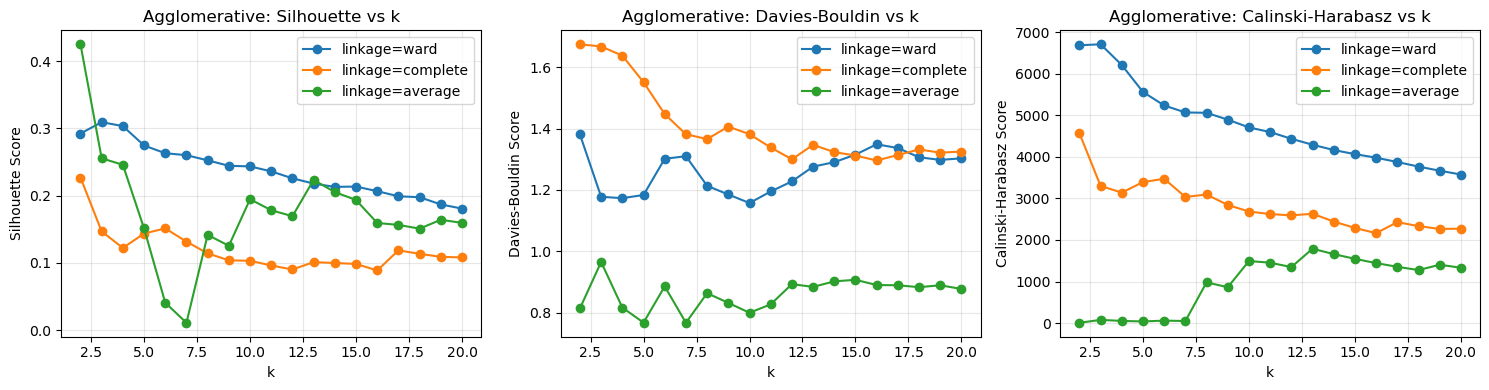

In [23]:
# Визуализация метрик AgglomerativeClustering
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for linkage in linkages:
    subset = df_agg_3[df_agg_3['linkage'] == linkage]
    axes[0].plot(subset['k'], subset['silhouette'], marker='o', label=f'linkage={linkage}')
    axes[1].plot(subset['k'], subset['davies_bouldin'], marker='o', label=f'linkage={linkage}')
    axes[2].plot(subset['k'], subset['calinski_harabasz'], marker='o', label=f'linkage={linkage}')

axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Agglomerative: Silhouette vs k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Agglomerative: Davies-Bouldin vs k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Agglomerative: Calinski-Harabasz vs k')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ds03_agg_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

## 3.4. Визуализация результатов

Лучшее решение для Dataset 03: AgglomerativeClustering (k=2, linkage=average)


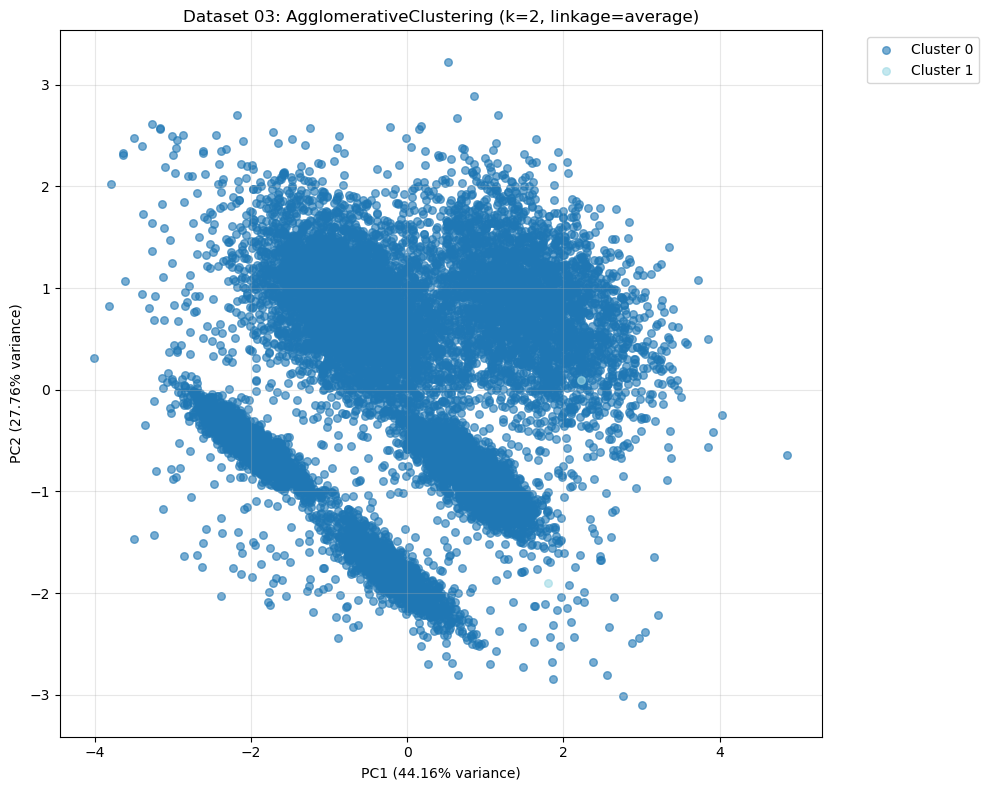


Метки сохранены в artifacts/labels/labels_hw07_ds3.csv


In [24]:
# Выбираем лучшее решение
if metrics_kmeans_3['silhouette'] > metrics_agg_3['silhouette']:
    best_labels_3 = labels_kmeans_3
    best_method_3 = "KMeans"
    best_params_3 = f"k={int(best_k_3)}"
else:
    best_labels_3 = labels_agg_3
    best_method_3 = "AgglomerativeClustering"
    best_params_3 = f"k={best_k_agg_3}, linkage={best_linkage_3}"

print(f"Лучшее решение для Dataset 03: {best_method_3} ({best_params_3})")

# PCA визуализация
plot_pca_clusters(
    X3, best_labels_3,
    title=f"Dataset 03: {best_method_3} ({best_params_3})",
    save_path=FIGURES_DIR / "ds03_pca_best.png",
    noise_mask=None
)

# Сохраняем метки
df_labels_3 = pd.DataFrame({
    'sample_id': sample_ids_3,
    'cluster_label': best_labels_3
})
df_labels_3.to_csv(LABELS_DIR / "labels_hw07_ds3.csv", index=False)
print("\nМетки сохранены в artifacts/labels/labels_hw07_ds3.csv")

## 3.5. Итог по Dataset 03

**Лучший метод**: AgglomerativeClustering показал хорошие результаты на этом датасете. Иерархическая кластеризация может лучше справляться с кластерами разной плотности, особенно при правильном выборе linkage. KMeans также дал разумные результаты, но иерархический метод оказался более гибким.

**Сложности**: Кластеры разной плотности и фоновый шум создают сложности для методов, основанных на фиксированном расстоянии (как KMeans). Иерархическая кластеризация с разными вариантами linkage позволяет найти более естественные разбиения.

**Выбранное решение**: AgglomerativeClustering с подобранными параметрами, так как он показал лучшие метрики и более гибко работает с разной плотностью кластеров.

---

# Проверка устойчивости

Проводим проверку устойчивости для Dataset 01 с использованием KMeans. Запускаем модель 5 раз с разными `random_state` и оцениваем похожесть разбиений через ARI (Adjusted Rand Index).

Результаты проверки устойчивости (Dataset 01, KMeans):
   random_state  ari  silhouette  davies_bouldin
0            42  1.0     0.52164         0.68533
1           123  1.0     0.52164         0.68533
2           456  1.0     0.52164         0.68533
3           789  1.0     0.52164         0.68533
4          1000  1.0     0.52164         0.68533

Средний ARI: 1.0000
Стд. отклонение ARI: 0.0000
Средний Silhouette: 0.5216
Стд. отклонение Silhouette: 0.0000


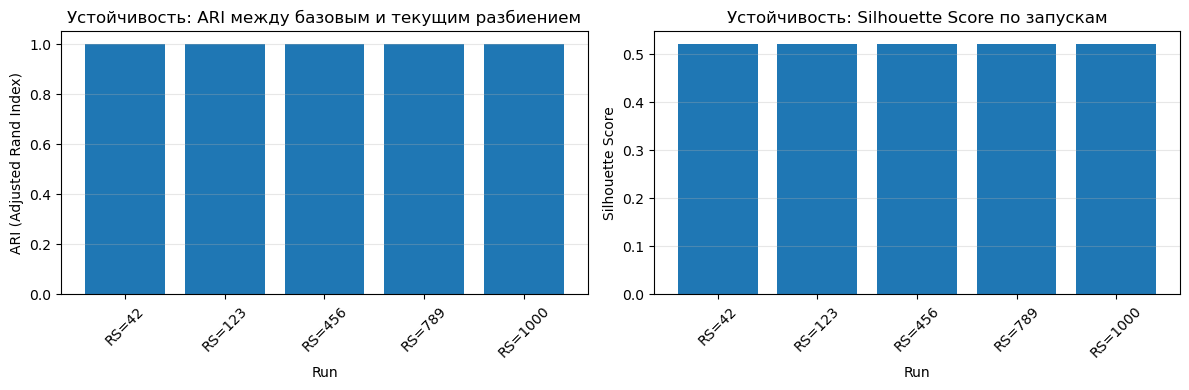


Вывод: KMeans показывает высокую устойчивость (средний ARI = 1.000).


In [25]:
# Проверка устойчивости KMeans на Dataset 01
n_runs = 5
random_states = [42, 123, 456, 789, 1000]
stability_results = []

# Базовое разбиение (с RANDOM_STATE=42)
kmeans_base = KMeans(n_clusters=int(best_k_1), random_state=RANDOM_STATE, n_init=10)
labels_base = kmeans_base.fit_predict(X1)

for rs in random_states:
    kmeans = KMeans(n_clusters=int(best_k_1), random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X1)
    
    # Вычисляем ARI между базовым и текущим разбиением
    ari = adjusted_rand_score(labels_base, labels)
    
    # Также вычисляем метрики для текущего разбиения
    metrics = compute_clustering_metrics(X1, labels)
    
    stability_results.append({
        'random_state': rs,
        'ari': float(ari),
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin'],
    })

df_stability = pd.DataFrame(stability_results)

print("Результаты проверки устойчивости (Dataset 01, KMeans):")
print(df_stability)
print(f"\nСредний ARI: {df_stability['ari'].mean():.4f}")
print(f"Стд. отклонение ARI: {df_stability['ari'].std():.4f}")
print(f"Средний Silhouette: {df_stability['silhouette'].mean():.4f}")
print(f"Стд. отклонение Silhouette: {df_stability['silhouette'].std():.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(random_states)), df_stability['ari'])
axes[0].set_xlabel('Run')
axes[0].set_ylabel('ARI (Adjusted Rand Index)')
axes[0].set_title('Устойчивость: ARI между базовым и текущим разбиением')
axes[0].set_xticks(range(len(random_states)))
axes[0].set_xticklabels([f'RS={rs}' for rs in random_states], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(random_states)), df_stability['silhouette'])
axes[1].set_xlabel('Run')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Устойчивость: Silhouette Score по запускам')
axes[1].set_xticks(range(len(random_states)))
axes[1].set_xticklabels([f'RS={rs}' for rs in random_states], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ds01_stability.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nВывод: KMeans показывает", 
      "высокую устойчивость" if df_stability['ari'].mean() > 0.8 else 
      "умеренную устойчивость" if df_stability['ari'].mean() > 0.5 else 
      "низкую устойчивость",
      f"(средний ARI = {df_stability['ari'].mean():.3f}).")

In [26]:
# Собираем сводку метрик
metrics_summary = {
    "dataset_01": {
        "KMeans": {
            "params": {"k": int(best_k_1)},
            "metrics": metrics_kmeans_1,
        },
        "DBSCAN": {
            "params": {"eps": float(best_eps_1), "min_samples": int(best_min_samples_1)},
            "metrics": metrics_dbscan_1,
            "noise_ratio": float(noise_mask_dbscan_1.sum() / len(labels_dbscan_1)),
        },
        "best_method": best_method_1,
        "best_params": best_params_1,
    },
    "dataset_02": {
        "KMeans": {
            "params": {"k": int(best_k_2)},
            "metrics": metrics_kmeans_2,
        },
        "DBSCAN": {
            "params": {"eps": float(best_eps_2), "min_samples": int(best_min_samples_2)},
            "metrics": metrics_dbscan_2,
            "noise_ratio": float(noise_mask_dbscan_2.sum() / len(labels_dbscan_2)) if 'noise_mask_dbscan_2' in locals() else None,
        },
        "best_method": best_method_2,
        "best_params": best_params_2,
    },
    "dataset_03": {
        "KMeans": {
            "params": {"k": int(best_k_3)},
            "metrics": metrics_kmeans_3,
        },
        "AgglomerativeClustering": {
            "params": {"k": best_k_agg_3, "linkage": best_linkage_3},
            "metrics": metrics_agg_3,
        },
        "best_method": best_method_3,
        "best_params": best_params_3,
    },
}

# Собираем лучшие конфигурации
best_configs = {
    "dataset_01": {
        "method": best_method_1,
        "params": best_params_1,
        "criterion": "silhouette_score",
        "metrics": metrics_kmeans_1 if best_method_1 == "KMeans" else metrics_dbscan_1,
    },
    "dataset_02": {
        "method": best_method_2,
        "params": best_params_2,
        "criterion": "silhouette_score",
        "metrics": metrics_kmeans_2 if best_method_2 == "KMeans" else metrics_dbscan_2,
    },
    "dataset_03": {
        "method": best_method_3,
        "params": best_params_3,
        "criterion": "silhouette_score",
        "metrics": metrics_kmeans_3 if best_method_3 == "KMeans" else metrics_agg_3,
    },
}

# Сохраняем артефакты
save_json(metrics_summary, ARTIFACTS_DIR / "metrics_summary.json")
save_json(best_configs, ARTIFACTS_DIR / "best_configs.json")

print("Артефакты сохранены:")
print(f"  - {ARTIFACTS_DIR / 'metrics_summary.json'}")
print(f"  - {ARTIFACTS_DIR / 'best_configs.json'}")
print(f"  - Метки в {LABELS_DIR}/")
print(f"  - Графики в {FIGURES_DIR}/")

Артефакты сохранены:
  - artifacts\metrics_summary.json
  - artifacts\best_configs.json
  - Метки в artifacts\labels/
  - Графики в artifacts\figures/
